# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
#Завантаження даних
df = pd.read_csv('credit_risk_dataset.csv', sep=None, engine='python')

#Розмір датасету
print(f"Розмір датасету: {df.shape}")
print(f"Кількість Позичальників: {df.shape[0]:,}")
print(f"Кількість парамертів: {df.shape[1]}")

Розмір датасету: (32581, 12)
Кількість Позичальників: 32,581
Кількість парамертів: 12


In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
#Наявність пропущенних значень
missing_data = df.isnull().sum()
missing_data

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [6]:
#Розподіл цільової змінної (статусу кредиту)
loan_status_dist = df['loan_status'].value_counts()
loan_status_dist

,count
loan_status,
0,25473
1,7108


In [7]:
#Розподіл цільової змінної (статусу кредиту) у %
loan_status_percent = df['loan_status'].value_counts(normalize=True) * 100
loan_status_percent

,proportion
loan_status,
0,78.183604
1,21.816396


Маємо справу з незбалансованим датасетом (78% vs 22%).


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [8]:
#Відсоток пропущенних значень
missing_percent = (missing_data / len(df)) * 100
missing_percent

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


In [9]:
#Заповнення пропусків медіаною
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [10]:
#Заповнення пропусків медіаною
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [11]:
#Статистичні дані (для числових змінних)
df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
#Перший та третій квартилі
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)

#Міжквартильний діапазон (IQR)
IQR = Q3 - Q1

#Межі
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Перший квартиль (person_income): Q1 = {Q1}")
print(f"Третій квартиль (person_income): Q3 = {Q3}")
print(f"Міжквартильний діапазон (person_income): IQR = {IQR}")
print(f"Межі для нормальних значень: від {lower_bound} до {upper_bound}")

Перший квартиль (person_income): Q1 = 38500.0
Третій квартиль (person_income): Q3 = 79200.0
Міжквартильний діапазон (person_income): IQR = 40700.0
Межі для нормальних значень: від -22550.0 до 140250.0


In [13]:
#Пошук викидів
outliers = df['person_income'][(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]

print(f"Кількість знайдених викидів: {len(outliers)}")

Кількість знайдених викидів: 1484


In [14]:
#Видалення викидів (залишились дані в межах [lower, upper])
df_clean = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)].copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31097 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31097 non-null  int64  
 1   person_income               31097 non-null  int64  
 2   person_home_ownership       31097 non-null  object 
 3   person_emp_length           31097 non-null  float64
 4   loan_intent                 31097 non-null  object 
 5   loan_grade                  31097 non-null  object 
 6   loan_amnt                   31097 non-null  int64  
 7   loan_int_rate               31097 non-null  float64
 8   loan_status                 31097 non-null  int64  
 9   loan_percent_income         31097 non-null  float64
 10  cb_person_default_on_file   31097 non-null  object 
 11  cb_person_cred_hist_length  31097 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.1+ MB


In [15]:
#Аналіз категоріальних змінних
df.nunique()

,0
person_age,58
person_income,4295
person_home_ownership,4
person_emp_length,36
loan_intent,6
loan_grade,7
loan_amnt,753
loan_int_rate,348
loan_status,2
loan_percent_income,77


In [16]:
#Аналіз категоріальних змінних (дані без викидів)
df_clean.nunique()

,0
person_age,56
person_income,3934
person_home_ownership,4
person_emp_length,35
loan_intent,6
loan_grade,7
loan_amnt,740
loan_int_rate,345
loan_status,2
loan_percent_income,76


In [17]:
#Статус кредиту за типом володіння житлом
status_person_home_ownership = df.groupby(['loan_status', 'person_home_ownership', ]).size().unstack()
status_person_home_ownership_pct = status_person_home_ownership.div(status_person_home_ownership.sum(axis=1), axis=0) * 100

fig_bar_1 = px.bar(
    status_person_home_ownership_pct.T,
    title='Статус кредиту за типом володіння житлом',
    labels={'value': 'Відсоток (%)', 'loan_status': 'Статус кредиту', 'person_home_ownership': 'Тип володіння житлом'},
    color_discrete_map={'0':'pink', '1':'orchid'},
    barmode='group'
)
fig_bar_1.show()

In [18]:
#Статус кредиту за метою кредиту
status_intent = df.groupby(['loan_status', 'loan_intent']).size().unstack()
status_intent_pct = status_intent.div(status_intent.sum(axis=1), axis=0) * 100

fig_bar_2 = px.bar(
    status_intent_pct.T,
    title='Статус кредиту за метою кредиту',
    labels={'value': 'Відсоток (%)', 'loan_status': 'Статус кредиту', 'loan_intent': 'Мета кредиту'},
    color_discrete_map={'0':'pink', '1':'orchid'},
    barmode='group'
)
fig_bar_2.show()

In [19]:
#Статус кредиту за кредитним рейтингом
status_grade = df.groupby(['loan_status', 'loan_grade']).size().unstack()
status_grade_pct = status_grade.div(status_grade.sum(axis=1), axis=0) * 100

fig_bar_3 = px.bar(
    status_grade_pct.T,
    title='Статус кредиту за кредитним рейтингом',
    labels={'value': 'Відсоток (%)', 'loan_status': 'Статус кредиту', 'loan_grade': 'Кредитний рейтинг'},
    color_discrete_map={'0':'pink', '1':'orchid'},
    barmode='group'
)
fig_bar_3.show()

In [20]:
#Статус кредиту за історією дефолту
status_default = df.groupby(['loan_status', 'cb_person_default_on_file']).size().unstack()
status_default_pct = status_default.div(status_default.sum(axis=1), axis=0) * 100

fig_bar_4 = px.bar(
    status_default_pct.T,
    title='Статус кредиту за історією дефолту',
    labels={'value': 'Відсоток (%)', 'loan_status': 'Статус кредиту', 'cb_person_default_on_file': 'Історія дефолту'},
    color_discrete_map={'0':'pink', '1':'orchid'},
    barmode='group'
)
fig_bar_4.show()


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [21]:
#Датафрейм тільки з числовими метриками
df_metrics = df[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']].dropna()

#Матриця кореляцій
correlation_matrix = df_metrics.corr()
correlation_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.161454,0.050787,0.011853,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.135164,0.266820,0.000746,-0.144449,-0.254471,0.117987
person_emp_length,0.161454,0.135164,1.000000,0.113851,-0.051262,-0.082182,-0.054134,0.143069
loan_amnt,0.050787,0.266820,0.113851,1.000000,0.139483,0.105376,0.572612,0.041967
loan_int_rate,0.011853,0.000746,-0.051262,0.139483,1.000000,0.319360,0.114514,0.015762
loan_status,-0.021629,-0.144449,-0.082182,0.105376,0.319360,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054134,0.572612,0.114514,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.143069,0.041967,0.015762,-0.015529,-0.031690,1.000000


In [22]:
#Heatmap кореляційної матриці
fig_hm = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='PiYG',
    title='Кореляційна матриця',
    labels=dict(color="Кореляція")
)
fig_hm.update_layout(height=500)
fig_hm.show()

In [23]:
#Датафрейм тільки з числовими метриками (дані без викидів)
df_clean_metrics = df_clean[['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']].dropna()

#Матриця кореляцій (дані без викидів)
correlation_matrix_clean = df_clean_metrics.corr()
correlation_matrix_clean

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.081485,0.155934,0.036407,0.009655,-0.016522,-0.023383,0.869909
person_income,0.081485,1.000000,0.188611,0.385604,-0.034314,-0.254228,-0.329516,0.057592
person_emp_length,0.155934,0.188611,1.000000,0.103383,-0.056518,-0.082116,-0.041463,0.134844
loan_amnt,0.036407,0.385604,0.103383,1.000000,0.130542,0.123433,0.642413,0.025947
loan_int_rate,0.009655,-0.034314,-0.056518,0.130542,1.000000,0.320203,0.119758,0.014897
loan_status,-0.016522,-0.254228,-0.082116,0.123433,0.320203,1.000000,0.379806,-0.010769
loan_percent_income,-0.023383,-0.329516,-0.041463,0.642413,0.119758,0.379806,1.000000,-0.014664
cb_person_cred_hist_length,0.869909,0.057592,0.134844,0.025947,0.014897,-0.010769,-0.014664,1.000000


In [24]:
#Heatmap кореляційної матриці (дані без викидів)
fig_hm_clean = px.imshow(
    correlation_matrix_clean,
    text_auto='.2f',
    color_continuous_scale='PiYG',
    title='Кореляційна матриця',
    labels=dict(color="Кореляція")
)
fig_hm_clean.update_layout(height=500)
fig_hm_clean.show()

In [25]:
all_cat_cols = df.select_dtypes('object').columns.tolist()
all_cat_cols

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [26]:
#Категоріальні колонки для кодування
selected_cat_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

#One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=selected_cat_cols, drop_first=True)
df_encoded.head()

,person_home_ownership,loan_intent,loan_grade,loan_status,cb_person_default_on_file,person_age_21,person_age_22,person_age_23,person_age_24,person_age_25,...,cb_person_cred_hist_length_21,cb_person_cred_hist_length_22,cb_person_cred_hist_length_23,cb_person_cred_hist_length_24,cb_person_cred_hist_length_25,cb_person_cred_hist_length_26,cb_person_cred_hist_length_27,cb_person_cred_hist_length_28,cb_person_cred_hist_length_29,cb_person_cred_hist_length_30
0,RENT,PERSONAL,D,1,Y,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,OWN,EDUCATION,B,0,N,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,MORTGAGE,MEDICAL,C,1,N,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,RENT,MEDICAL,C,1,N,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,RENT,MEDICAL,C,1,Y,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [27]:
#One-Hot Encoding (дані без викидів)
df_clean_encoded = pd.get_dummies(df_clean, columns=selected_cat_cols, drop_first=True)
df_clean_encoded.head()

,person_home_ownership,loan_intent,loan_grade,loan_status,cb_person_default_on_file,person_age_21,person_age_22,person_age_23,person_age_24,person_age_25,...,cb_person_cred_hist_length_21,cb_person_cred_hist_length_22,cb_person_cred_hist_length_23,cb_person_cred_hist_length_24,cb_person_cred_hist_length_25,cb_person_cred_hist_length_26,cb_person_cred_hist_length_27,cb_person_cred_hist_length_28,cb_person_cred_hist_length_29,cb_person_cred_hist_length_30
0,RENT,PERSONAL,D,1,Y,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,OWN,EDUCATION,B,0,N,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,MORTGAGE,MEDICAL,C,1,N,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,RENT,MEDICAL,C,1,N,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,RENT,MEDICAL,C,1,Y,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [28]:
#Видалення непотрібних колонок
exclude_cols = ['loan_status'] + all_cat_cols
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]
feature_cols_clean = [col for col in df_clean_encoded.columns if col not in exclude_cols]


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [29]:
#Визначення X (ознаки) та y (ціль)
X = df_encoded[feature_cols]
y = df_encoded['loan_status']

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 5589
Розмір вибірки: 32581


In [30]:
#Визначення X (ознаки) та y (ціль) (дані без викидів)
X_clean = df_clean_encoded[feature_cols_clean]
y_clean = df_clean_encoded['loan_status']

print(f"Кількість ознак: {X_clean.shape[1]}")
print(f"Розмір вибірки: {X_clean.shape[0]}")

Кількість ознак: 5208
Розмір вибірки: 31097


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  #Зберігаємо пропорції класів
)

print(f"Train: {X_train.shape[0]} клієнтів")
print(f"Test: {X_test.shape[0]} клієнтів")
print(f"Відтік в train: {y_train.mean():.1%}")
print(f"Відтік в test: {y_test.mean():.1%}")

Train: 26064 клієнтів
Test: 6517 клієнтів
Відтік в train: 21.8%
Відтік в test: 21.8%


In [32]:
X_clean_train, X_clean_test, y_clean_train, y_clean_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean  #Зберігаємо пропорції класів
)

print(f"Train: {X_clean_train.shape[0]} клієнтів")
print(f"Test: {X_clean_test.shape[0]} клієнтів")
print(f"Відтік в train: {y_clean_train.mean():.1%}")
print(f"Відтік в test: {y_clean_test.mean():.1%}")

Train: 24877 клієнтів
Test: 6220 клієнтів
Відтік в train: 22.4%
Відтік в test: 22.4%


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler_clear = StandardScaler()
X_clean_train_scaled = scaler_clear.fit_transform(X_clean_train)
X_clean_test_scaled = scaler_clear.transform(X_clean_test)

In [35]:
from sklearn.linear_model import LogisticRegression

#Створення та навчання моделі
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [36]:
model

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
#Створення та навчання моделі (дані без викидів)
model_clean = LogisticRegression(random_state=42, max_iter=1000)
model_clean.fit(X_clean_train_scaled, y_clean_train)

print("Модель навчена!")

Модель навчена!


In [38]:
model_clean

LogisticRegression(max_iter=1000, random_state=42)

In [39]:
#Прогнозування класів
y_pred = model.predict(X_test_scaled)

#Прогнозування ймовірності
y_pred_proba = model.predict_proba(X_test_scaled)
y_pred_proba

array([[9.92205773e-01, 7.79422707e-03],
       [9.82338785e-01, 1.76612148e-02],
       [9.99912912e-01, 8.70878915e-05],
       ...,
       [9.64592804e-01, 3.54071961e-02],
       [9.33667536e-01, 6.63324640e-02],
       [9.92264343e-01, 7.73565748e-03]])

In [40]:
#Прогнозування класів (дані без викидів)
y_clean_pred = model_clean.predict(X_clean_test_scaled)

#Прогнозування ймовірності (дані без викидів)
y_clean_pred_proba = model_clean.predict_proba(X_clean_test_scaled)
y_clean_pred_proba

array([[8.82347171e-01, 1.17652829e-01],
       [9.99991408e-01, 8.59240834e-06],
       [9.99984908e-01, 1.50915985e-05],
       ...,
       [4.83782758e-01, 5.16217242e-01],
       [9.49217942e-01, 5.07820581e-02],
       [9.98222571e-01, 1.77742903e-03]])

In [41]:
(y_pred_proba[:, 1]>0.6).astype(int)
(y_clean_pred_proba[:, 1]>0.6).astype(int)

array([0, 0, 0, ..., 0, 0, 0])

In [42]:
#Приклад прогнозів для перших 10 позичальників
sample_predictions = pd.DataFrame({
    'Реальний статус кредиту': y_test.values[:10],
    'Прогноз': y_pred[:10],
    'Ймовірність оплати': y_pred_proba[:10, 0].round(3),
    'Ймовірність дефолту': y_pred_proba[:10, 1].round(3)
})
print(sample_predictions)

   Реальний статус кредиту  Прогноз  Ймовірність оплати  Ймовірність дефолту
0                        0        0               0.992                0.008
1                        0        0               0.982                0.018
2                        0        0               1.000                0.000
3                        0        0               0.975                0.025
4                        0        1               0.000                1.000
5                        0        0               0.773                0.227
6                        0        0               0.969                0.031
7                        0        0               0.935                0.065
8                        0        0               0.923                0.077
9                        1        1               0.033                0.967


In [43]:
#Приклад прогнозів для перших 10 позичальників (дані без викидів)
sample_predictions_clean = pd.DataFrame({
    'Реальний статус кредиту': y_clean_test.values[:10],
    'Прогноз': y_clean_pred[:10],
    'Ймовірність оплати': y_clean_pred_proba[:10, 0].round(3),
    'Ймовірність дефолту': y_clean_pred_proba[:10, 1].round(3)
})
print(sample_predictions_clean)

   Реальний статус кредиту  Прогноз  Ймовірність оплати  Ймовірність дефолту
0                        0        0               0.882                0.118
1                        0        0               1.000                0.000
2                        0        0               1.000                0.000
3                        0        0               0.975                0.025
4                        0        1               0.179                0.821
5                        0        0               0.995                0.005
6                        1        0               0.651                0.349
7                        1        0               0.988                0.012
8                        0        0               0.913                0.087
9                        1        0               0.936                0.064



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


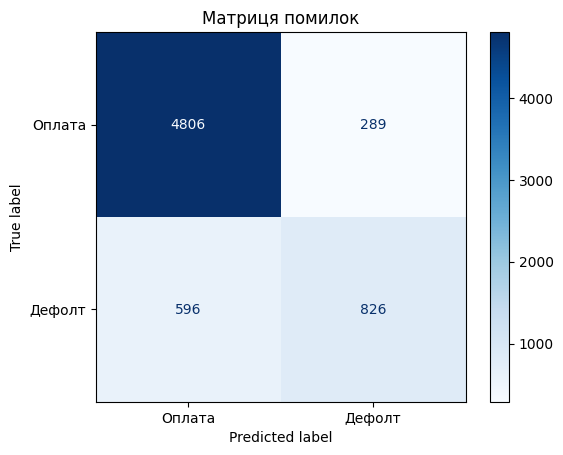

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Оплата', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

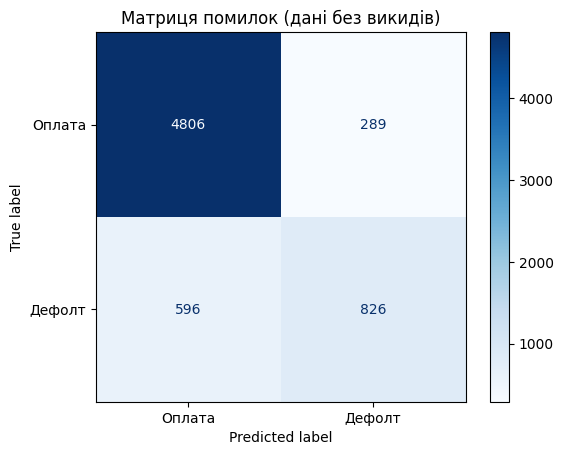

In [45]:
#Confusion matrix (дані без викидів)
cm_clean = confusion_matrix(y_clean_test, y_clean_pred)

disp_clean = ConfusionMatrixDisplay(confusion_matrix=cm_clean, display_labels=['Оплата', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок (дані без викидів)')
plt.show()

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Основні метрики (accuracy, precision, recall, f1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Метрики якості моделі:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

Метрики якості моделі:
Accuracy (Точність):    0.864
Precision (Влучність):  0.741
Recall (Повнота):       0.581
F1-score:               0.651


In [47]:
#Основні метрики (accuracy, precision, recall, f1) (дані без викидів)
accuracy_clean = accuracy_score(y_clean_test, y_clean_pred)
precision_clean = precision_score(y_clean_test, y_clean_pred)
recall_clean = recall_score(y_clean_test, y_clean_pred)
f1_clean = f1_score(y_clean_test, y_clean_pred)

print("Метрики якості моделі (дані без викидів):")
print(f"Accuracy (Точність):    {accuracy_clean:.3f}")
print(f"Precision (Влучність):  {precision_clean:.3f}")
print(f"Recall (Повнота):       {recall_clean:.3f}")
print(f"F1-score:               {f1_clean:.3f}")

Метрики якості моделі (дані без викидів):
Accuracy (Точність):    0.858
Precision (Влучність):  0.728
Recall (Повнота):       0.583
F1-score:               0.647


In [48]:
from sklearn.metrics import roc_curve, roc_auc_score

#ROC-крива
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

#Візуалізація
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

AUC = 0.860, отже у нас - хороша модель.

In [49]:
#ROC-крива (дані без викидів)
fpr_clean, tpr_clean, thresholds_clean = roc_curve(y_clean_test, y_clean_pred_proba[:, 1])
auc_clean = roc_auc_score(y_clean_test, y_clean_pred_proba[:, 1])

# Візуалізація (дані без викидів)
fig_clean = go.Figure()
fig_clean.add_trace(go.Scatter(x=fpr_clean, y=tpr_clean, mode='lines', name=f'ROC (AUC = {auc_clean:.3f})'))
fig_clean.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig_clean.update_layout(
    title='ROC-крива (дані без викидів)',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig_clean.show()

AUC = 0.854, отже у нас - хороша модель.

In [50]:
#Коефіцієнти моделі
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5224,loan_int_rate_10.99,0.576303,0.576303
3927,person_income_130000,-0.471339,0.471339
3959,person_income_135000,-0.373906,0.373906
2277,person_income_58650,0.367139,0.367139
3988,person_income_140000,-0.357213,0.357213
...,...,...,...
2952,person_income_74970,0.000000,0.000000
2953,person_income_74984,0.000000,0.000000
541,person_income_27864,0.000000,0.000000
542,person_income_27880,0.000000,0.000000


In [51]:
#Коефіцієнти моделі (дані без викидів)
feature_importance_clean = pd.DataFrame({
    'feature': X_clean.columns,
    'coefficient': model_clean.coef_[0],
    'abs_coefficient': np.abs(model_clean.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance_clean

,feature,coefficient,abs_coefficient
3737,person_income_110000,-0.765467,0.765467
3894,person_income_125000,-0.482583,0.482583
3671,person_income_105000,-0.439504,0.439504
3957,person_income_135000,-0.430098,0.430098
4847,loan_int_rate_10.99,0.414094,0.414094
...,...,...,...
4662,loan_amnt_21125,0.000000,0.000000
1104,person_income_37876,0.000000,0.000000
1101,person_income_37818,0.000000,0.000000
1041,person_income_36816,0.000000,0.000000



---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [52]:
#Аналіз різних порогів
thresholds = np.arange(0.1, 0.9, 0.01)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Візуалізація
fig_line = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig_line.show()

Оптимальний поріг який оптимізує точність - 0.33.

In [53]:
#Аналіз різних порогів (дані без викидів)
thresholds_clean = np.arange(0.1, 0.9, 0.01)
metrics_by_threshold_clean = []

for threshold in thresholds_clean:
    y_clean_pred_custom = (y_clean_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold_clean.append({
        'threshold': threshold,
        'precision': precision_score(y_clean_test, y_clean_pred_custom),
        'recall': recall_score(y_clean_test, y_clean_pred_custom),
        'f1': f1_score(y_clean_test, y_clean_pred_custom)
    })

metrics_df_clean = pd.DataFrame(metrics_by_threshold_clean)

# Візуалізація
fig_line_clean = px.line(
    metrics_df_clean.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення (дані без викидів)',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig_line_clean.show()

Оптимальний поріг який оптимізує точність - 0.34.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Навчання альтернативних моделей
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.864      0.741   0.581  0.651  0.860
1        Decision Tree     0.800      0.679   0.156  0.254  0.568
2        Random Forest     0.866      0.760   0.562  0.646  0.897


Найкращий результат на тестовому наборі дає модель Random Forest. На другому місці - модель Logistic Regression. В той час як модель Decision Tree дає набаго гірший результат, в порівнянні з двома попередніми.





In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Навчання альтернативних моделей (дані без викидів)
models_clean = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results_clean = []
for name, model in models_clean.items():
    model_clean.fit(X_clean_train_scaled, y_clean_train)
    y_clean_pred = model_clean.predict(X_clean_test_scaled)
    y_clean_pred_proba = model_clean.predict_proba(X_clean_test_scaled)[:, 1]

    results_clean.append({
        'Model': name,
        'Accuracy': accuracy_score(y_clean_test, y_clean_pred),
        'Precision': precision_score(y_clean_test, y_clean_pred),
        'Recall': recall_score(y_clean_test, y_clean_pred),
        'F1': f1_score(y_clean_test, y_clean_pred),
        'AUC': roc_auc_score(y_clean_test, y_clean_pred_proba)
    })

results_df_clean = pd.DataFrame(results_clean).round(3)
print(results_df_clean)

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.858      0.728   0.583  0.647  0.854
1        Decision Tree     0.858      0.728   0.583  0.647  0.854
2        Random Forest     0.858      0.728   0.583  0.647  0.854


На очищенних даних без викидів усі 3 моделі дають однаковий результат.